# More Visualizations

## Setup and Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm
from scipy.spatial.distance import pdist
import seaborn as sns
import scipy.cluster.hierarchy as sch
import plotly.express as px
from glob import glob
import re
import nltk

In [3]:
LIB = pd.read_csv('data/pg2591-LIB.csv')
LIB['label'] = LIB.doc_title +  " " + "Volume:" + LIB.volume.astype('str')
LIB.set_index('doc_title', inplace=True)
LIB.head()

,volume,label
doc_title,,
THE GOLDEN BIRD,1,THE GOLDEN BIRD Volume:1
HANS IN LUCK,1,HANS IN LUCK Volume:1
JORINDA AND JORINDEL,1,JORINDA AND JORINDEL Volume:1
THE TRAVELLING MUSICIANS,1,THE TRAVELLING MUSICIANS Volume:1
OLD SULTAN,1,OLD SULTAN Volume:1


In [4]:
OHCO = ['doc_title','para_num','sentence_num','token_num']

In [5]:
TFIDF = pd.read_csv('data/pg2591-REDUC_TFIDF.csv').set_index(OHCO[:1])
TFIDF

,king,man,old,we,upon,father,himself,shall,take,cried,...,appear,cooking,grass,backwards,finding,doors,sides,searched,started,hide
doc_title,,,,,,,,,,,,,,,,,,,,,
ASHPUTTEL,0.111674,0.004770,0.004200,0.004200,0.014623,0.102368,0.011775,0.014623,0.010177,0.021935,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.028603
BRIAR ROSE,0.263257,0.017991,0.063370,0.000000,0.041367,0.000000,0.000000,0.020683,0.012795,0.006894,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
CAT AND MOUSE IN PARTNERSHIP,0.000000,0.000000,0.000000,0.038154,0.004744,0.000000,0.000000,0.009488,0.004402,0.014232,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
CAT-SKIN,0.452256,0.000000,0.000000,0.021486,0.014026,0.035704,0.000000,0.004675,0.026031,0.000000,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.036579
CLEVER ELSIE,0.000000,0.038482,0.000000,0.081325,0.000000,0.030031,0.000000,0.035392,0.000000,0.011797,...,0.046151,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
THE WEDDING OF MRS. FOX - PART II,0.000000,0.011494,0.040485,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
THE WHITE SNAKE,0.200396,0.028013,0.008222,0.090446,0.028627,0.000000,0.030734,0.007157,0.000000,0.028627,...,0.000000,0.0,0.055993,0.0,0.055993,0.0,0.000000,0.000000,0.000000,0.000000
THE WILLOW-WREN AND THE BEAR,0.098323,0.000000,0.014792,0.081358,0.006438,0.000000,0.000000,0.032188,0.011947,0.019313,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.050366,0.000000,0.050366,0.000000


## Making a Sigs Table

In [6]:
V = TFIDF.astype(bool).sum().to_frame('df') #TFIDF_BAG.mean().to_frame('mean_tfidf')
V.index.name = 'term_str'
N = len(TFIDF)
V['dp'] = V.df / N
V['di'] = np.log2(1/V.dp)
V['dh'] = V.dp * V.di
V.sample(5)

,df,dp,di,dh
term_str,,,,
passing,8,0.129032,2.954196,0.381187
every,35,0.564516,0.824913,0.465677
lighted,7,0.112903,3.146841,0.355289
four,14,0.225806,2.146841,0.484771
forward,10,0.161290,2.632268,0.424559


In [7]:
sig_thresh = .125
SIGS = V[V.dh >= sig_thresh]
(len(SIGS) / len(V)) * 100, len(SIGS)
SIGS.sample(5)

,df,dp,di,dh
term_str,,,,
too,44,0.709677,0.494765,0.351123
himself,45,0.725806,0.462343,0.335572
use,18,0.290323,1.784271,0.518014
passed,22,0.354839,1.494765,0.530400
scarcely,15,0.241935,2.047306,0.495316


In [8]:
TFIDF_SIGS = TFIDF[SIGS.index].copy()
TFIDF_SIGS

term_str,king,man,old,we,upon,father,himself,shall,take,cried,...,appear,cooking,grass,backwards,finding,doors,sides,searched,started,hide
doc_title,,,,,,,,,,,,,,,,,,,,,
ASHPUTTEL,0.111674,0.004770,0.004200,0.004200,0.014623,0.102368,0.011775,0.014623,0.010177,0.021935,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.028603
BRIAR ROSE,0.263257,0.017991,0.063370,0.000000,0.041367,0.000000,0.000000,0.020683,0.012795,0.006894,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
CAT AND MOUSE IN PARTNERSHIP,0.000000,0.000000,0.000000,0.038154,0.004744,0.000000,0.000000,0.009488,0.004402,0.014232,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
CAT-SKIN,0.452256,0.000000,0.000000,0.021486,0.014026,0.035704,0.000000,0.004675,0.026031,0.000000,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.036579
CLEVER ELSIE,0.000000,0.038482,0.000000,0.081325,0.000000,0.030031,0.000000,0.035392,0.000000,0.011797,...,0.046151,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
THE WEDDING OF MRS. FOX - PART II,0.000000,0.011494,0.040485,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
THE WHITE SNAKE,0.200396,0.028013,0.008222,0.090446,0.028627,0.000000,0.030734,0.007157,0.000000,0.028627,...,0.000000,0.0,0.055993,0.0,0.055993,0.0,0.000000,0.000000,0.000000,0.000000
THE WILLOW-WREN AND THE BEAR,0.098323,0.000000,0.014792,0.081358,0.006438,0.000000,0.000000,0.032188,0.011947,0.019313,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.050366,0.000000,0.050366,0.000000


## Make normalized tables

In [9]:
L0 = TFIDF_SIGS.astype('bool').astype('int')    # Binary (Pseudo L)
L1 = TFIDF_SIGS.apply(lambda x: x / x.sum(), 1) # Probabilistic
L2 = TFIDF_SIGS.apply(lambda x: x / norm(x), 1) # Pythagorean, AKA Euclidean

## Making Pairs Table

In [10]:
PAIRS = pd.DataFrame(index=pd.MultiIndex.from_product([LIB.index.tolist(), LIB.index.tolist()])).reset_index()
PAIRS = PAIRS[PAIRS.level_0 < PAIRS.level_1].set_index(['level_0','level_1'])
PAIRS

Empty DataFrame
Columns: []
Index: [(THE GOLDEN BIRD, THE TRAVELLING MUSICIANS), (THE GOLDEN BIRD, THE STRAW, THE COAL, AND THE BEAN), (THE GOLDEN BIRD, THE TWELVE DANCING PRINCESSES), (THE GOLDEN BIRD, THE WILLOW-WREN AND THE BEAR), (THE GOLDEN BIRD, THE GOOSE-GIRL), (THE GOLDEN BIRD, THE VALIANT LITTLE TAILOR), (THE GOLDEN BIRD, THE MOUSE, THE BIRD, AND THE SAUSAGE), (THE GOLDEN BIRD, THE ROBBER BRIDEGROOM), (THE GOLDEN BIRD, TOM THUMB), (THE GOLDEN BIRD, THE OLD MAN AND HIS GRANDSON), (THE GOLDEN BIRD, THE LITTLE PEASANT), (THE GOLDEN BIRD, THE PINK), (THE GOLDEN BIRD, THE MISER IN THE BUSH), (THE GOLDEN BIRD, THE WHITE SNAKE), (THE GOLDEN BIRD, THE WOLF AND THE SEVEN LITTLE KIDS), (THE GOLDEN BIRD, THE QUEEN BEE), (THE GOLDEN BIRD, THE JUNIPER-TREE), (THE GOLDEN BIRD, THE TURNIP), (THE GOLDEN BIRD, THE THREE LANGUAGES), (THE GOLDEN BIRD, THE RAVEN), (THE GOLDEN BIRD, THE GOLDEN GOOSE), (THE GOLDEN BIRD, THE WATER OF LIFE), (THE GOLDEN BIRD, THE TWELVE HUNTSMEN), (THE GOLDEN BIRD, THE KING OF THE GOLDEN MOUNTAIN), (THE GOLDEN BIRD, THE SEVEN RAVENS), (THE GOLDEN BIRD, THE WEDDING OF MRS. FOX - PART I), (THE GOLDEN BIRD, THE WEDDING OF MRS. FOX - PART II), (THE GOLDEN BIRD, THE SALAD), (THE GOLDEN BIRD, THE STORY OF THE YOUTH WHO WENT FORTH TO LEARN WHAT FEAR WAS), (HANS IN LUCK, THE GOLDEN BIRD), (HANS IN LUCK, JORINDA AND JORINDEL), (HANS IN LUCK, THE TRAVELLING MUSICIANS), (HANS IN LUCK, OLD SULTAN), (HANS IN LUCK, THE STRAW, THE COAL, AND THE BEAN), (HANS IN LUCK, THE DOG AND THE SPARROW), (HANS IN LUCK, THE TWELVE DANCING PRINCESSES), (HANS IN LUCK, THE FISHERMAN AND HIS WIFE), (HANS IN LUCK, THE WILLOW-WREN AND THE BEAR), (HANS IN LUCK, THE FROG-PRINCE), (HANS IN LUCK, THE GOOSE-GIRL), (HANS IN LUCK, THE ADVENTURES OF CHANTICLEER AND PARTLET), (HANS IN LUCK, RAPUNZEL), (HANS IN LUCK, THE VALIANT LITTLE TAILOR), (HANS IN LUCK, HANSEL AND GRETEL), (HANS IN LUCK, THE MOUSE, THE BIRD, AND THE SAUSAGE), (HANS IN LUCK, MOTHER HOLLE), (HANS IN LUCK, THE ROBBER BRIDEGROOM), (HANS IN LUCK, TOM THUMB), (HANS IN LUCK, RUMPELSTILTSKIN), (HANS IN LUCK, THE OLD MAN AND HIS GRANDSON), (HANS IN LUCK, THE LITTLE PEASANT), (HANS IN LUCK, SWEETHEART ROLAND), (HANS IN LUCK, SNOWDROP), (HANS IN LUCK, THE PINK), (HANS IN LUCK, THE MISER IN THE BUSH), (HANS IN LUCK, THE WHITE SNAKE), (HANS IN LUCK, THE WOLF AND THE SEVEN LITTLE KIDS), (HANS IN LUCK, THE QUEEN BEE), (HANS IN LUCK, THE ELVES AND THE SHOEMAKER), (HANS IN LUCK, THE JUNIPER-TREE), (HANS IN LUCK, THE TURNIP), (HANS IN LUCK, THE THREE LANGUAGES), (HANS IN LUCK, THE FOX AND THE CAT), (HANS IN LUCK, THE FOUR CLEVER BROTHERS), (HANS IN LUCK, LILY AND THE LION), (HANS IN LUCK, THE FOX AND THE HORSE), (HANS IN LUCK, THE BLUE LIGHT), (HANS IN LUCK, THE RAVEN), (HANS IN LUCK, THE GOLDEN GOOSE), (HANS IN LUCK, THE WATER OF LIFE), (HANS IN LUCK, THE TWELVE HUNTSMEN), (HANS IN LUCK, THE KING OF THE GOLDEN MOUNTAIN), (HANS IN LUCK, THE SEVEN RAVENS), (HANS IN LUCK, THE WEDDING OF MRS. FOX - PART I), (HANS IN LUCK, THE WEDDING OF MRS. FOX - PART II), (HANS IN LUCK, THE SALAD), (HANS IN LUCK, THE STORY OF THE YOUTH WHO WENT FORTH TO LEARN WHAT FEAR WAS), (HANS IN LUCK, KING GRISLY-BEARD), (HANS IN LUCK, IRON HANS), (HANS IN LUCK, SNOW-WHITE AND ROSE-RED), (JORINDA AND JORINDEL, THE GOLDEN BIRD), (JORINDA AND JORINDEL, THE TRAVELLING MUSICIANS), (JORINDA AND JORINDEL, OLD SULTAN), (JORINDA AND JORINDEL, THE STRAW, THE COAL, AND THE BEAN), (JORINDA AND JORINDEL, THE DOG AND THE SPARROW), (JORINDA AND JORINDEL, THE TWELVE DANCING PRINCESSES), (JORINDA AND JORINDEL, THE FISHERMAN AND HIS WIFE), (JORINDA AND JORINDEL, THE WILLOW-WREN AND THE BEAR), (JORINDA AND JORINDEL, THE FROG-PRINCE), (JORINDA AND JORINDEL, THE GOOSE-GIRL), (JORINDA AND JORINDEL, THE ADVENTURES OF CHANTICLEER AND PARTLET), (JORINDA AND JORINDEL, RAPUNZEL), (JORINDA AND JORINDEL, THE VALIANT LITTLE TAILOR), (JORINDA AND JORINDEL, THE MOUSE, THE BIRD, AND THE SAUSAGE), (JORINDA AND JORINDEL, MOTHER HOLLE), (JORINDA AND JORINDEL, T

In [11]:
PAIRS['cityblock'] = pdist(TFIDF_SIGS, 'cityblock')
PAIRS['cityblock1'] = pdist(L1, 'cityblock')
PAIRS['cityblock2'] = pdist(L2, 'cityblock')
PAIRS['euclidean'] = pdist(TFIDF_SIGS, 'euclidean')
PAIRS['euclidean2'] = pdist(L2, 'euclidean') # Should be the same as cosine (colinear)
PAIRS['cosine'] = pdist(TFIDF_SIGS, 'cosine')
PAIRS['cosine2'] = pdist(L2, 'cosine')
PAIRS['jaccard'] = pdist(L0, 'jaccard')
PAIRS['dice'] = pdist(L0, 'dice')
PAIRS['js'] = pdist(L1, 'jensenshannon') 
PAIRS.head()

cityblock  cityblock1  \
level_0         level_1                                                    
THE GOLDEN BIRD THE TRAVELLING MUSICIANS           16.881053    1.550497   
                THE STRAW, THE COAL, AND THE BEAN  14.132769    1.775956   
                THE TWELVE DANCING PRINCESSES      14.445528    1.355137   
                THE WILLOW-WREN AND THE BEAR       15.828150    1.701982   
                THE GOOSE-GIRL                     16.637674    1.779704   

                                                   cityblock2  euclidean  \
level_0         level_1                                                    
THE GOLDEN BIRD THE TRAVELLING MUSICIANS            16.881053   1.271611   
                THE STRAW, THE COAL, AND THE BEAN   14.132769   1.394062   
                THE TWELVE DANCING PRINCESSES       14.445528   1.129778   
                THE WILLOW-WREN AND THE BEAR        15.828150   1.365810   
                THE GOOSE-GIRL                      16.637674   1.373784   

                                                   euclidean2    cosine  \
level_0         level_1                                                   
THE GOLDEN BIRD THE TRAVELLING MUSICIANS             1.271611  0.808497   
                THE STRAW, THE COAL, AND THE BEAN    1.394062  0.971704   
                THE TWELVE DANCING PRINCESSES        1.129778  0.638200   
                THE WILLOW-WREN AND THE BEAR         1.365810  0.932719   
                THE GOOSE-GIRL                       1.373784  0.943642   

                                                    cosine2   jaccard  \
level_0         level_1                                                 
THE GOLDEN BIRD THE TRAVELLING MUSICIANS           0.808497  0.724880   
                THE STRAW, THE COAL, AND THE BEAN  0.971704  0.815920   
                THE TWELVE DANCING PRINCESSES      0.638200  0.657343   
                THE WILLOW-WREN AND THE BEAR       0.932719  0.776650   
                THE GOOSE-GIRL                     0.943642  0.844737   

                                                       dice        js  
level_0         level_1                                                
THE GOLDEN BIRD THE TRAVELLING MUSICIANS           0.568480  0.692176  
                THE STRAW, THE COAL, AND THE BEAN  0.689076  0.766025  
                THE TWELVE DANCING PRINCESSES      0.489583  0.621419  
                THE WILLOW-WREN AND THE BEAR       0.634855  0.743582  
                THE GOOSE-GIRL                     0.731207  0.762913

## Making a Scatter Plot

In [12]:
def plot_doc_in_terms(t1, t2):
    # ax = L1.plot.scatter(t1, t2, figsize=(10,10))
    # for i, row in L1.iterrows():
    #     label = LIB.loc[i].label
    #     color = 'green' if "Volume:1" in label else 'blue'
    #     x_pad = L1[t1].max() * .01
    #     ax.annotate(label, xy=(row[t1] + x_pad, row[t2]), c=color)
    # sns.despine()
    # plt.title("Documents in Term Space", fontweight='bold')
    # plt.show()
    # Used AI to help turn plot into plotly for better visuals so labels wouldn't overlap
    fig = px.scatter(L1.reset_index(), x=t1, y=t2, hover_name='doc_title', height=1000, width=1200, color=LIB.volume.astype('category'), color_discrete_sequence=['pink', 'blue'])
    return fig

In [13]:
fig1=plot_doc_in_terms('king', 'miller')
fig1.update_layout(legend_title_text='Volume')
fig1.write_image('scatter.png')
fig1.show()



I wanted to look at the difference between the royal and working class again, so I looked at the document signifiganace of "king" and piller". It seems that king is more signifgant in more stories that miller, especially in volume one. King however has very low signifgance in most stories since there are a lot of points close to the x-axis in both volumes. The stories might have a king as a background chracters, but focus more on a prince or princess .Miller is more signifagant than king in two stores, "The Salad" and "The Robber Bridegrooom". Both of these stories are in volume 2. Perhaps volume 2 introudced more stories of the working class.

## Making a Heatmap

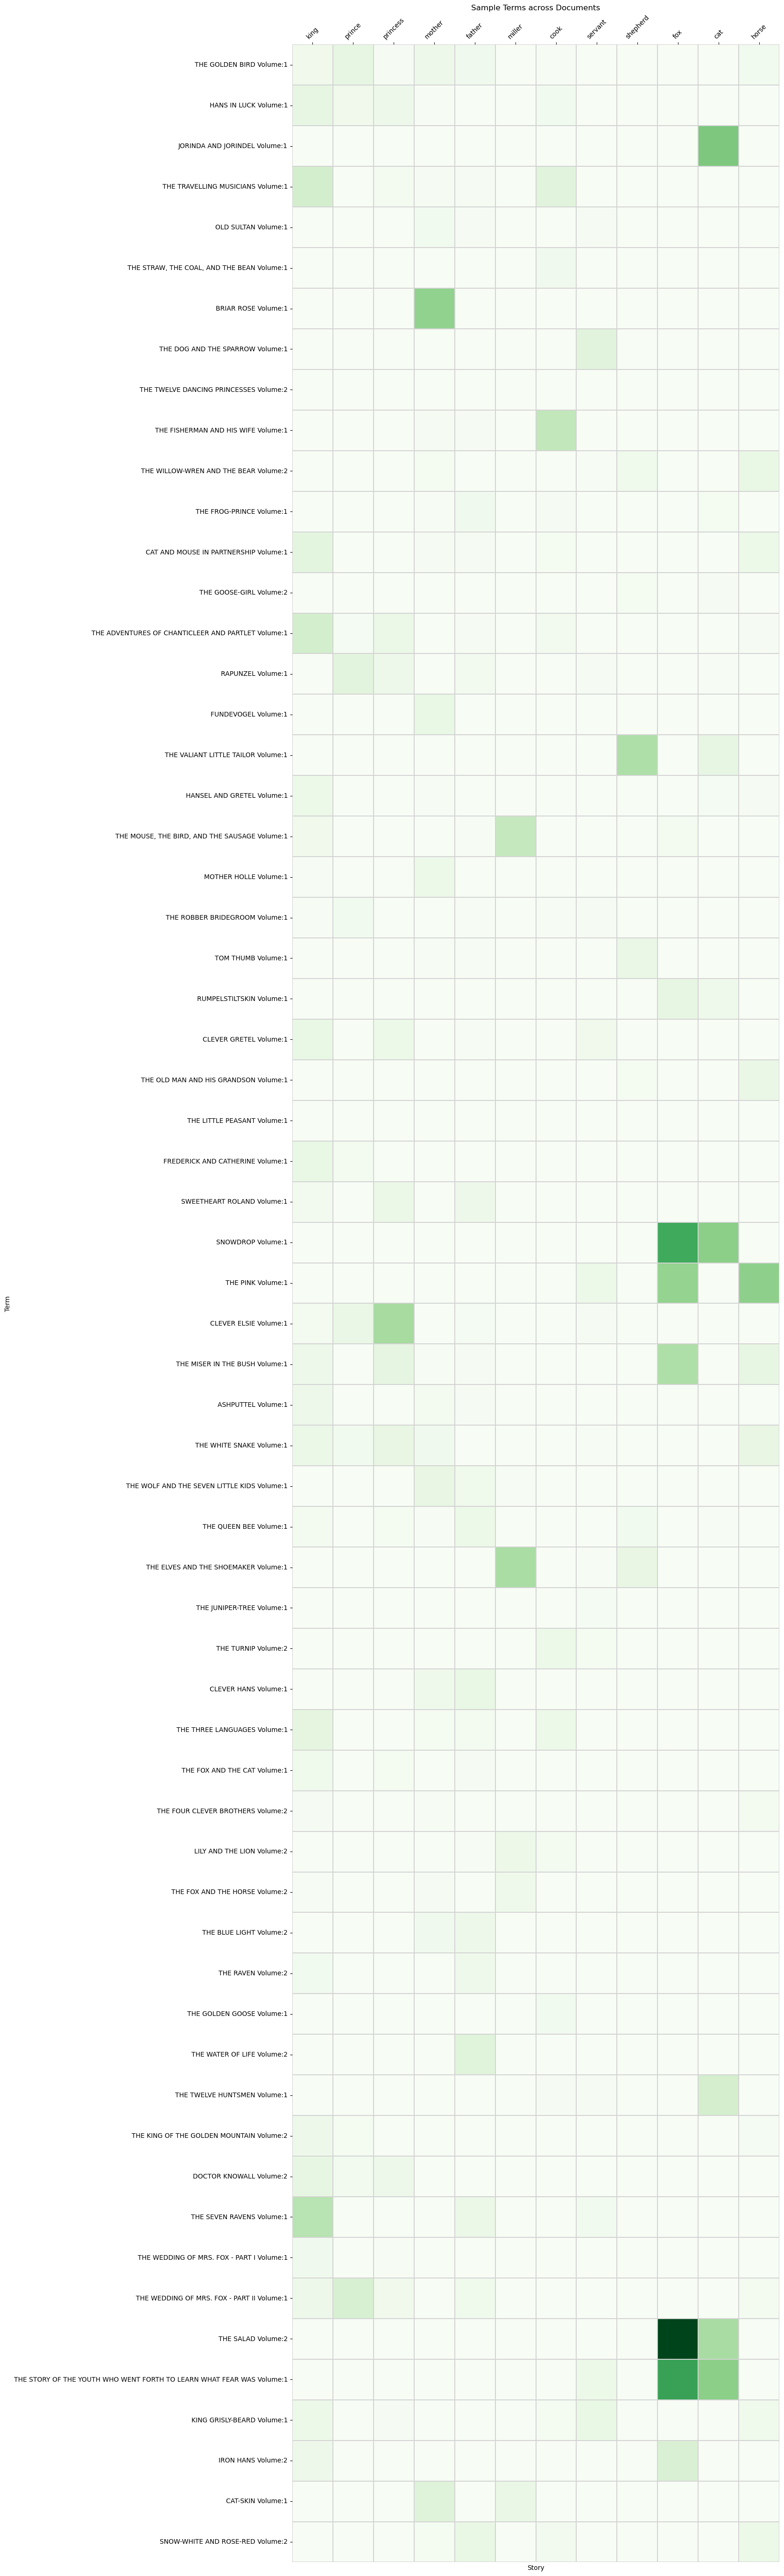

In [14]:
sample_terms = "king prince princess mother father miller cook servant shepherd fox cat horse".split()
plt.figure(figsize=(100, 70))
ax = sns.heatmap(L1[sample_terms], 
            yticklabels = LIB.label.values,
            cmap="Greens", linewidth=.01, linecolor="lightgray", square=True, cbar=None)
ax.xaxis.tick_top()
ax.set(xlabel="Story", ylabel="Term",title="Sample Terms across Documents")
plt.xticks(rotation=45)
plt.savefig('heatmap.png')
plt.show()


I wanted to make a heatmap with some working class and royal words to see if they were signifigant in certain stories. I also included some animal words in my sample terms because they were common words accross the short stories. I found that "miller" is very siginfigant in "The Elves and the Shoemaker". This makes sense because a shoemaker is also working class, so maybe surrounding characters in the story are also working class. The term "princess" seems to be associated with "Clever Elise". Animal words are very signifigant For example, example fox and cat are signifigant in Volume I's  "The Story of the Youth who Went Forth to Learn what Fear Was" and Volume's II's "The Salad". Animals are a common theme accross fairytales.

## Making Clusters

In [15]:
def hac(sim_method='cosine', linkage_method='complete', color_thresh=.3, figsize=(10, 10)):

    # Get the similarities among pairs
    sims = PAIRS[sim_method]
    
    # Generate the cluster tree
    tree = sch.linkage(sims, method=linkage_method)
    
    # Get labels for the leaves
    labels = LIB.label.values
    
    # Create a dendrogram from the tree
    sch.dendrogram(tree, 
        labels=labels, 
        orientation="left", 
        count_sort=True,
        distance_sort=True,
        above_threshold_color='.75',
        color_threshold=color_thresh
    )

    # Show threshhold
    ax = plt.gca()
    ax.axvline(color_thresh, c='gray', ls='--')

    # Change the appearance of ticks, tick labels, and gridlines
    plt.tick_params(axis='both', which='major', labelsize=5    )

    # Remove borders
    sns.despine(left=True, bottom=True)

    # Add title
    plt.title(f"{sim_method} + {linkage_method} ({color_thresh})", y=1.05)

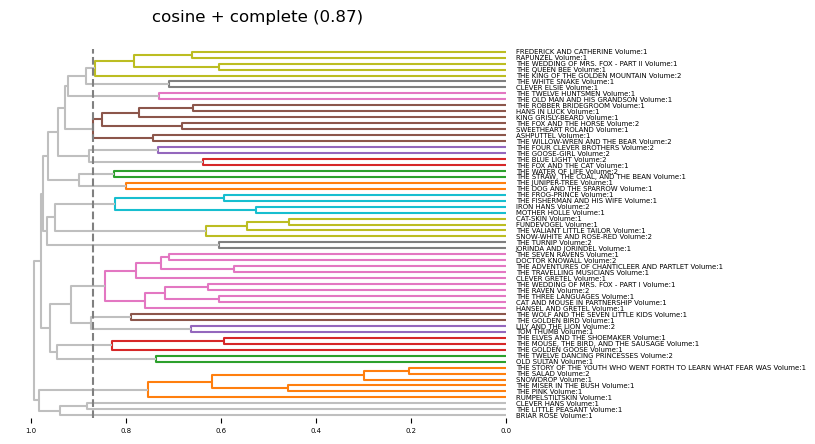

In [16]:
hac('cosine', linkage_method='complete', color_thresh=.87)


There is no stark difference between the volumes. There are a few times where a story from Volume I and a story from Volune II are in the same two-leaf clade, such as "The King of Golden Mountain" and "The Queen Bee". "The Little Peasant" and "Briar Rose" break off from the denogram early. This surprises me I thought Briar Rose would be more similar to other princess stories since it is the origin of Sleeping Beauty according to my research.